In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


# 1. Data Loading

The datasets were loaded using pandas. The analysis includes:

- Fear & Greed Index
- Hyperliquid Historical Trades

In [5]:
# Load datasets

fear = pd.read_csv("../data/fear_greed_index.csv")
trades = pd.read_csv("../data/historical_data.csv")

print("Fear & Greed Shape :", fear.shape)
print("Historical Trades Shape :", trades.shape)


Fear & Greed Shape : (2644, 4)
Historical Trades Shape : (211224, 16)


# 2. Data Cleaning

The following preprocessing steps were performed:

- Converted timestamps
- Removed unmatched records
- Checked missing values
- Checked duplicates

In [6]:
print("Fear & Greed Dataset")
display(fear.head(5))

print("\nHistorical Trades Dataset")
display(trades.head(5))

Fear & Greed Dataset


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05



Historical Trades Dataset


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [7]:
print("Fear & Greed Dataset\n")
fear.info()

print("\nHistorical Dataset\n")
trades.info()

Fear & Greed Dataset

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 127.5 KB

Historical Dataset

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    2

In [8]:
print("Fear Dataset Missing Values")
display(fear.isnull().sum())

print("\nHistorical Dataset Missing Values")
display(trades.isnull().sum())


Fear Dataset Missing Values


timestamp         0
value             0
classification    0
date              0
dtype: int64


Historical Dataset Missing Values


Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [9]:
print("Fear Dataset Duplicates :", fear.duplicated().sum())
print("Historical Dataset Duplicates :", trades.duplicated().sum())

Fear Dataset Duplicates : 0
Historical Dataset Duplicates : 0


In [10]:
display(fear.describe(include='all'))

display(trades.describe(include='all'))

,timestamp,value,classification,date
count,2.644000e+03,2644.000000,2644,2644
unique,NaN,NaN,5,2644
top,NaN,NaN,Fear,2018-02-01
freq,NaN,NaN,781,1
mean,1.631899e+09,46.981089,NaN,NaN
std,6.597967e+07,21.827680,NaN,NaN
min,1.517463e+09,5.000000,NaN,NaN
25%,1.574811e+09,28.000000,NaN,NaN
50%,1.631900e+09,46.000000,NaN,NaN
75%,1.688989e+09,66.000000,NaN,NaN


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
count,211224,211224,211224.000000,2.112240e+05,2.112240e+05,211224,211224,2.112240e+05,211224,211224.000000,211224,2.112240e+05,211224,211224.000000,2.112240e+05,2.112240e+05
unique,32,246,NaN,NaN,NaN,2,27977,NaN,12,NaN,101184,NaN,2,NaN,NaN,NaN
top,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,NaN,NaN,NaN,SELL,14-02-2025 00:31,NaN,Open Long,NaN,0x00000000000000000000000000000000000000000000...,NaN,True,NaN,NaN,NaN
freq,40184,68005,NaN,NaN,NaN,108528,441,NaN,49895,NaN,9032,NaN,128403,NaN,NaN,NaN
mean,NaN,NaN,11414.723350,4.623365e+03,5.639451e+03,NaN,NaN,-2.994625e+04,NaN,48.749001,NaN,6.965388e+10,NaN,1.163967,5.628549e+14,1.737744e+12
std,NaN,NaN,29447.654868,1.042729e+05,3.657514e+04,NaN,NaN,6.738074e+05,NaN,919.164828,NaN,1.835753e+10,NaN,6.758854,3.257565e+14,8.689920e+09
min,NaN,NaN,0.000005,8.740000e-07,0.000000e+00,NaN,NaN,-1.433463e+07,NaN,-117990.104100,NaN,1.732711e+08,NaN,-1.175712,0.000000e+00,1.680000e+12
25%,NaN,NaN,4.854700,2.940000e+00,1.937900e+02,NaN,NaN,-3.762311e+02,NaN,0.000000,NaN,5.983853e+10,NaN,0.016121,2.810000e+14,1.740000e+12
50%,NaN,NaN,18.280000,3.200000e+01,5.970450e+02,NaN,NaN,8.472793e+01,NaN,0.000000,NaN,7.442939e+10,NaN,0.089578,5.620000e+14,1.740000e+12
75%,NaN,NaN,101.580000,1.879025e+02,2.058960e+03,NaN,NaN,9.337278e+03,NaN,5.792797,NaN,8.335543e+10,NaN,0.393811,8.460000e+14,1.740000e+12


In [11]:
# Fear & Greed date
fear['date'] = pd.to_datetime(fear['date'])

# Historical data timestamp
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True
)

# Create Date column for merging
trades['Date'] = trades['Timestamp IST'].dt.date
fear['Date'] = fear['date'].dt.date

print("Date Conversion Successful")

Date Conversion Successful


In [12]:
merged = trades.merge(
    fear[['Date','classification','value']],
    on='Date',
    how='left'
)

print("Merged Shape:", merged.shape)

merged.head()

Merged Shape: (211224, 19)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


In [13]:
merged[['classification','value']].isnull().sum()

classification    6
value             6
dtype: int64

In [14]:
merged[merged['classification'].isnull()][
    ['Timestamp IST', 'Date']
]

,Timestamp IST,Date
727,2024-10-26 04:44:00,2024-10-26
728,2024-10-26 04:52:00,2024-10-26
729,2024-10-26 04:52:00,2024-10-26
730,2024-10-26 04:52:00,2024-10-26
731,2024-10-26 04:52:00,2024-10-26
732,2024-10-26 04:53:00,2024-10-26


In [15]:
merged = merged.dropna(subset=['classification'])

print("New Shape:", merged.shape)


New Shape: (211218, 19)


In [16]:
merged[['classification','value']].isnull().sum()

classification    0
value             0
dtype: int64

In [17]:
print(merged.shape)

print(merged.columns.tolist())

(211218, 19)
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'Date', 'classification', 'value']


In [18]:
merged.rename(columns={
    'classification':'Market Sentiment',
    'value':'Fear Greed Index',
    'Closed PnL':'PnL'
}, inplace=True)

merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,Market Sentiment,Fear Greed Index
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


In [19]:
merged[['PnL','Execution Price','Size USD','Fee']].describe()

,PnL,Execution Price,Size USD,Fee
count,211218.000000,211218.000000,2.112180e+05,211218.000000
mean,48.549304,11415.047529,5.639192e+03,1.163960
std,917.989791,29448.010305,3.657557e+04,6.758948
min,-117990.104100,0.000005,0.000000e+00,-1.175712
25%,0.000000,4.858550,1.937900e+02,0.016121
50%,0.000000,18.280000,5.970200e+02,0.089572
75%,5.790132,101.895000,2.058878e+03,0.393774
max,135329.090100,109004.000000,3.921431e+06,837.471593


In [20]:
summary = merged.groupby("Market Sentiment").agg({

    "PnL":["mean","median","sum"],

    "Fee":"mean",

    "Size USD":"mean",

    "Execution Price":"mean"

})

summary

PnL                            Fee     Size USD  \
                       mean median           sum      mean         mean   
Market Sentiment                                                          
Extreme Fear      34.537862    0.0  7.391102e+05  1.116291  5349.731843   
Extreme Greed     67.892861    0.0  2.715171e+06  0.675902  3112.251565   
Fear              54.290400    0.0  3.357155e+06  1.495172  7816.109931   
Greed             42.743559    0.0  2.150129e+06  1.254372  5736.884375   
Neutral           34.307718    0.0  1.292921e+06  1.044798  4782.732661   

                 Execution Price  
                            mean  
Market Sentiment                  
Extreme Fear         7054.795108  
Extreme Greed        6082.195865  
Fear                14152.620222  
Greed               13411.276344  
Neutral             12393.692779

In [21]:
merged["Win"] = merged["PnL"] > 0

win_rate = merged.groupby("Market Sentiment")["Win"].mean()*100

win_rate

Market Sentiment
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Win, dtype: float64

Interpretation of Your Results
### 1. Trader Performance by Market Sentiment
| Market Sentiment | Average PnL |   Win Rate |
| ---------------- | ----------: | ---------: |
| Extreme Greed    |   **67.89** | **46.49%** |
| Fear             |   **54.29** | **42.08%** |
| Greed            |   **42.74** | **38.48%** |
| Neutral          |   **34.31** | **39.70%** |
| Extreme Fear     |   **34.54** | **37.06%** |

### Insight 1

Extreme Greed days produced the highest average trader profitability (67.89) and the highest win rate (46.49%). This suggests that traders, on average, performed better during periods of strong positive market sentiment.

### Insight 2

Extreme Fear resulted in the lowest win rate (37.06%) and one of the lowest average PnL values (34.54). This indicates that highly negative market sentiment is associated with lower trading success.

### Insight 3

Fear days had higher average trade sizes (≈7816 USD) than Greed days (≈5737 USD), yet their win rate (42.08%) remained below Extreme Greed (46.49%). This suggests that increasing position size alone does not guarantee better performance; market conditions also matter.


# 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) was performed to understand the relationship between market sentiment and trader performance. The analysis focuses on profitability, trading activity, position size, transaction fees, and market behavior under different sentiment conditions.

The following visualizations provide insights into how trader performance varies across different market sentiment categories.

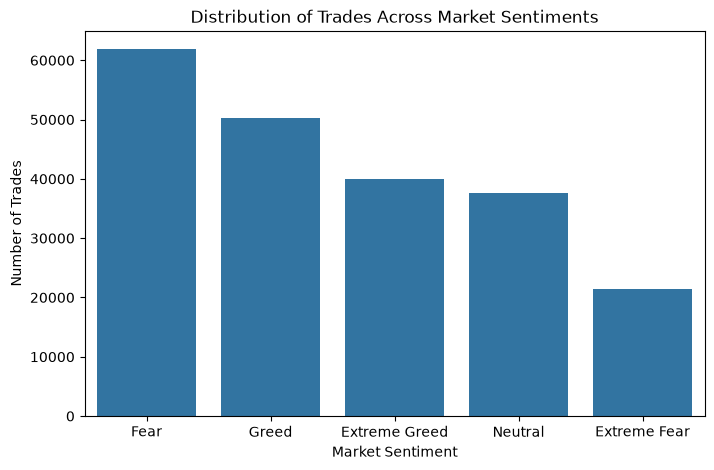

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=merged,
    x="Market Sentiment",
    order=merged["Market Sentiment"].value_counts().index
)

plt.title("Distribution of Trades Across Market Sentiments")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.show()

In [23]:
import seaborn as sns
print(sns.__version__)

0.13.2


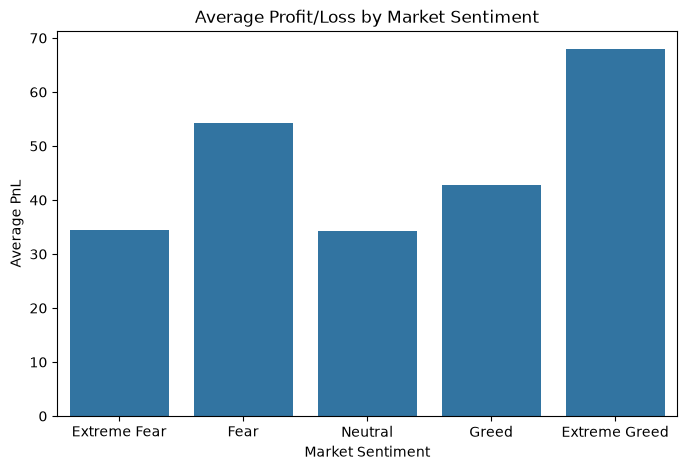

In [24]:
plt.figure(figsize=(8,5))
order = [
    "Extreme Fear",
    "Fear",
    "Neutral",
    "Greed",
    "Extreme Greed"
]
sns.barplot(
    data=merged,
    x="Market Sentiment",
    y="PnL",
    estimator=np.mean,
    errorbar=None,
    order=order
)

plt.title("Average Profit/Loss by Market Sentiment")
plt.ylabel("Average PnL")
plt.show()

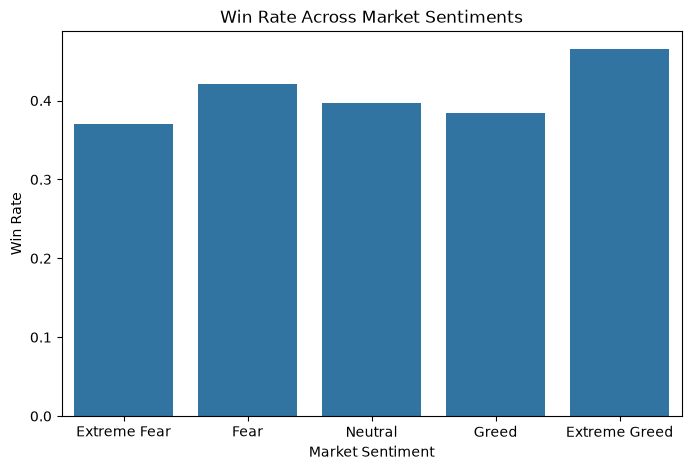

In [25]:
order = [
    "Extreme Fear",
    "Fear",
    "Neutral",
    "Greed",
    "Extreme Greed"
]

plt.figure(figsize=(8,5))

sns.barplot(
    data=merged,
    x="Market Sentiment",
    y="Win",
    estimator=np.mean,
    order=order,
    ci=None
)

plt.ylabel("Win Rate")
plt.title("Win Rate Across Market Sentiments")

plt.show()

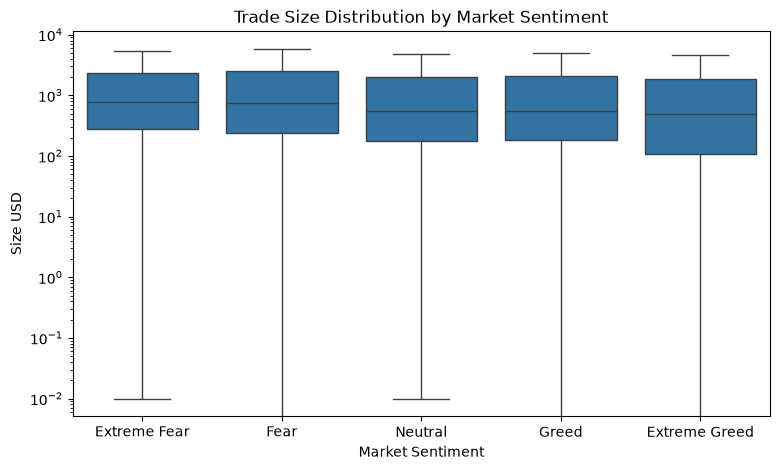

In [26]:
plt.figure(figsize=(9,5))
order = [
    "Extreme Fear", 
    "Fear",
    "Neutral",
    "Greed",
    "Extreme Greed"
]
sns.boxplot(
    data=merged,
    x="Market Sentiment",
    y="Size USD",
    order=order,
    showfliers=False
)

plt.yscale("log")

plt.title("Trade Size Distribution by Market Sentiment")

plt.show()

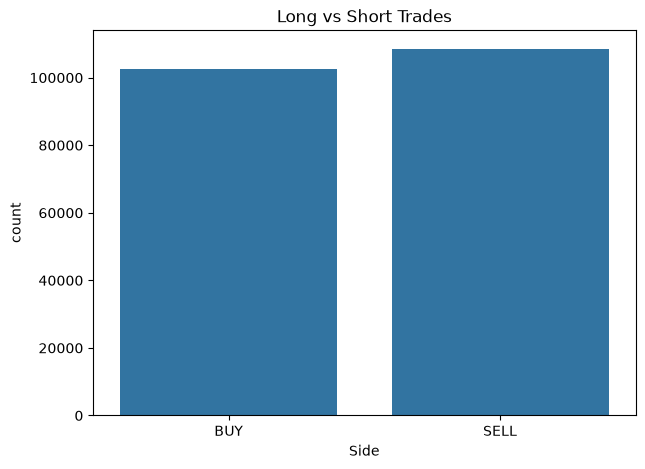

In [27]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=merged,
    x="Side"
)

plt.title("Long vs Short Trades")

plt.show()

In [28]:
merged = merged.rename(columns={
    "classification": "Market Sentiment",
    "value": "Fear_Greed_Index",
    "Closed PnL": "PnL"
})

In [29]:
print(merged.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'Date', 'Market Sentiment', 'Fear Greed Index', 'Win']


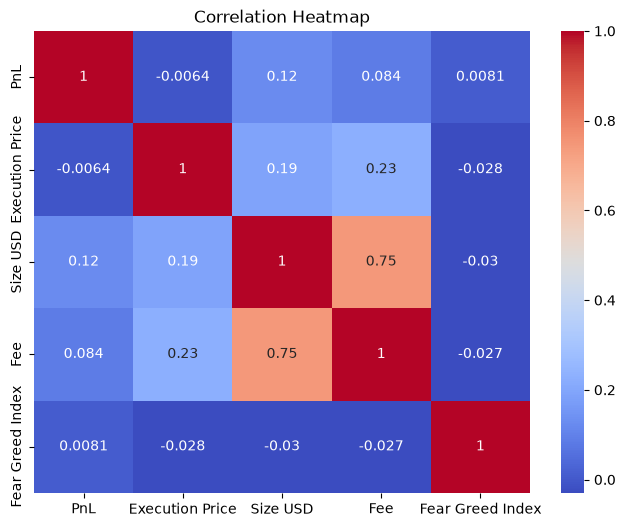

In [30]:
plt.figure(figsize=(8,6))

corr = merged[[
    "PnL",
    "Execution Price",
    "Size USD",
    "Fee",
    "Fear Greed Index"
]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

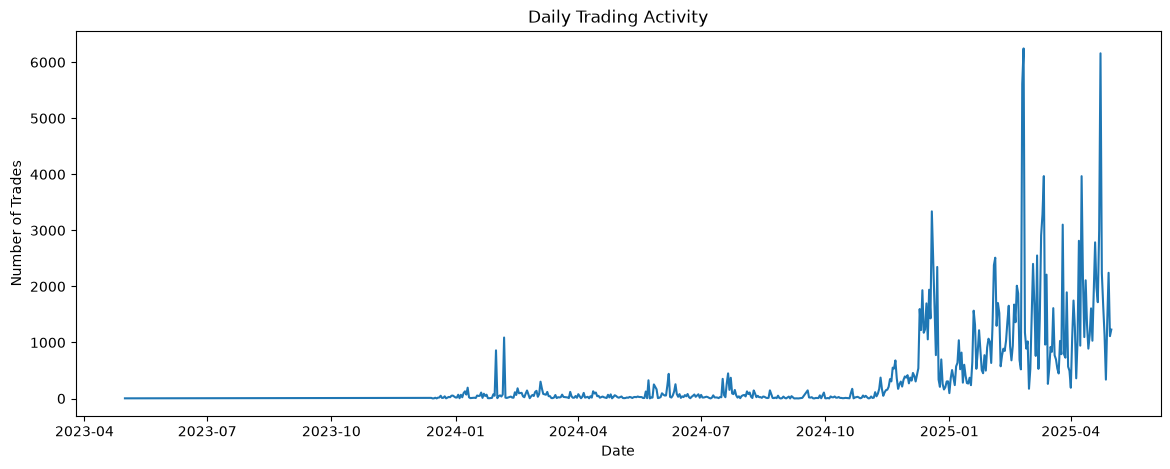

In [31]:
daily = merged.groupby("Date").size()

plt.figure(figsize=(14,5))

daily.plot()

plt.title("Daily Trading Activity")

plt.ylabel("Number of Trades")

plt.show()

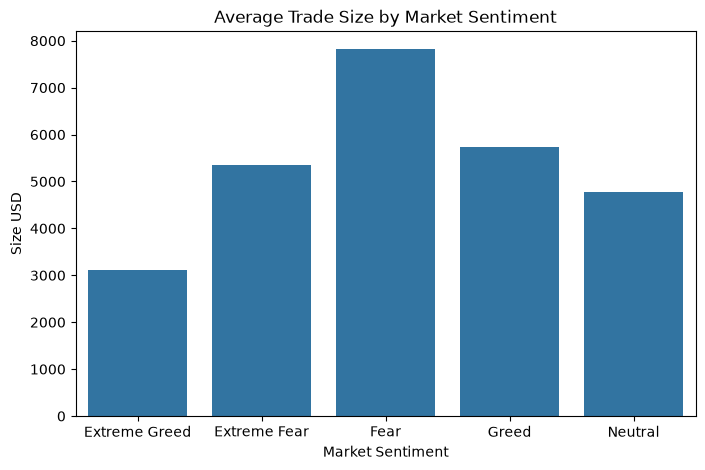

In [32]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=merged,
    x="Market Sentiment",
    y="Size USD",
    estimator=np.mean,
    errorbar=None
)

plt.title("Average Trade Size by Market Sentiment")

plt.show()

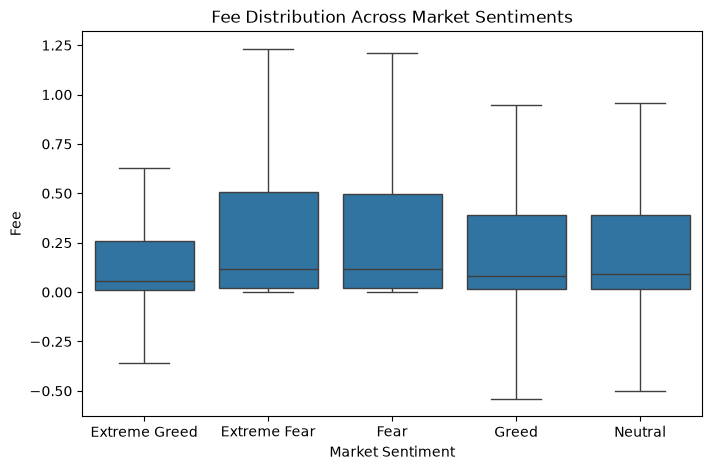

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=merged,
    x="Market Sentiment",
    y="Fee",
    showfliers=False
)

plt.title("Fee Distribution Across Market Sentiments")

plt.show()

# 4. Trader Segmentation

To better understand trader behavior, traders were segmented based on their activity level, profitability, and average position size.

The following segments were created:

- High Activity vs Low Activity Traders
- Consistent Winners vs Inconsistent Traders
- Large Position vs Small Position Traders

These segments help identify which types of traders perform better under different market sentiment conditions.

In [34]:
# Number of trades per trader

activity = merged.groupby("Account").size().reset_index(name="Trades")

activity.head()

,Account,Trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280
2,0x271b280974205ca63b716753467d5a371de622ab,3809
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239


In [35]:
median_trades = activity["Trades"].median()

activity["Activity"] = activity["Trades"].apply(
    lambda x: "High Activity" if x >= median_trades else "Low Activity"
)

activity.head()

,Account,Trades,Activity
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,High Activity
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,High Activity
2,0x271b280974205ca63b716753467d5a371de622ab,3809,High Activity
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,High Activity
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,Low Activity


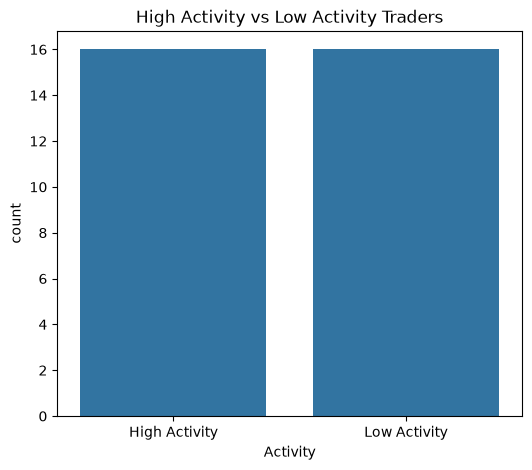

In [36]:
plt.figure(figsize=(6,5))

sns.countplot(data=activity, x="Activity")

plt.title("High Activity vs Low Activity Traders")

plt.show()

### Observation

The dataset was divided into High Activity and Low Activity traders based on the median number of trades executed by each account.

In [37]:
win_rate = merged.groupby("Account")["Win"].mean().reset_index()

win_rate.rename(columns={"Win":"Win Rate"}, inplace=True)

win_rate.head()

,Account,Win Rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


In [38]:
win_rate["Trader Type"] = np.where(
    win_rate["Win Rate"] >= 0.5,
    "Consistent Winner",
    "Inconsistent"
)

win_rate.head()

,Account,Win Rate,Trader Type
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612,Inconsistent
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720,Inconsistent
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917,Inconsistent
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585,Inconsistent
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914,Consistent Winner


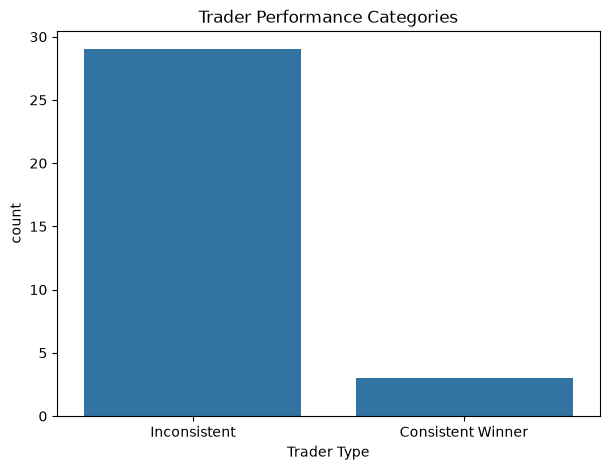

In [39]:
plt.figure(figsize=(7,5))

sns.countplot(data=win_rate, x="Trader Type")

plt.title("Trader Performance Categories")

plt.show()

### Observation

A trader is considered a Consistent Winner if more than 50% of their trades are profitable.

In [40]:
position = merged.groupby("Account")["Size USD"].mean().reset_index()

position.rename(columns={"Size USD":"Average Position"}, inplace=True)

position.head()

,Account,Average Position
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


In [41]:
median_position = position["Average Position"].median()

position["Position Type"] = np.where(
    position["Average Position"] >= median_position,
    "Large Position",
    "Small Position"
)

position.head()

,Account,Average Position,Position Type
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734,Large Position
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327,Small Position
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898,Large Position
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933,Small Position
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782,Small Position


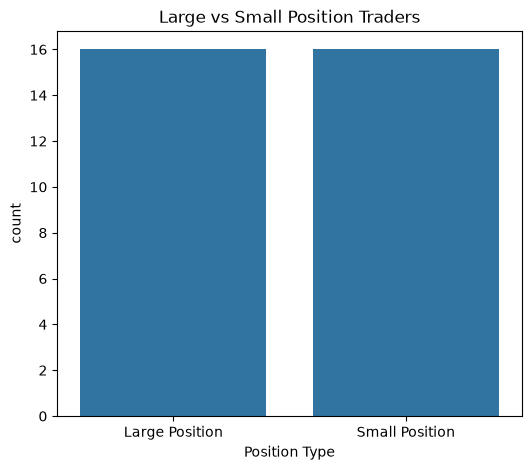

In [42]:
plt.figure(figsize=(6,5))

sns.countplot(data=position, x="Position Type")

plt.title("Large vs Small Position Traders")

plt.show()

### Observation

Since leverage information was unavailable in the dataset, average position size (USD) was used as a proxy for trading aggressiveness.

# Segment Insights

### High Activity Traders
High activity traders execute more trades and generally exhibit more aggressive trading behavior.

### Consistent Winners
These traders maintain a win rate above 50%, indicating stable profitability over time.

### Large Position Traders
Large position traders commit more capital per trade and therefore may be exposed to greater risk and reward.

## Correlation Analysis

A correlation heatmap is used to measure the strength of relationships among the numerical variables in the dataset. Values close to +1 indicate a strong positive relationship, while values close to −1 indicate a strong negative relationship.

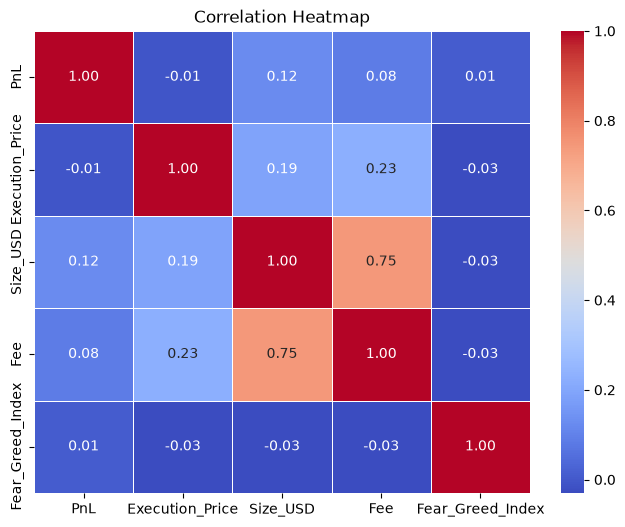

In [43]:
# Rename columns (only once if not already renamed)
merged = merged.rename(columns={
    "Fear Greed Index": "Fear_Greed_Index",
    "Execution Price": "Execution_Price",
    "Size USD": "Size_USD"
})

plt.figure(figsize=(8,6))

corr = merged[[
    "PnL",
    "Execution_Price",
    "Size_USD",
    "Fee",
    "Fear_Greed_Index"
]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

## Distribution of Profit and Loss

The distribution of PnL helps identify whether trader returns are normally distributed or contain significant outliers.

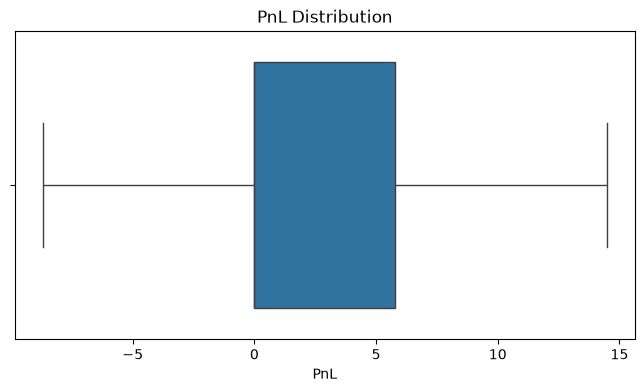

In [44]:
plt.figure(figsize=(8,4))

sns.boxplot(x=merged["PnL"], showfliers=False)

plt.title("PnL Distribution")
plt.xlabel("PnL")

plt.show()

## Daily Profit Trend

Daily cumulative PnL illustrates how overall trader profitability changes over time.

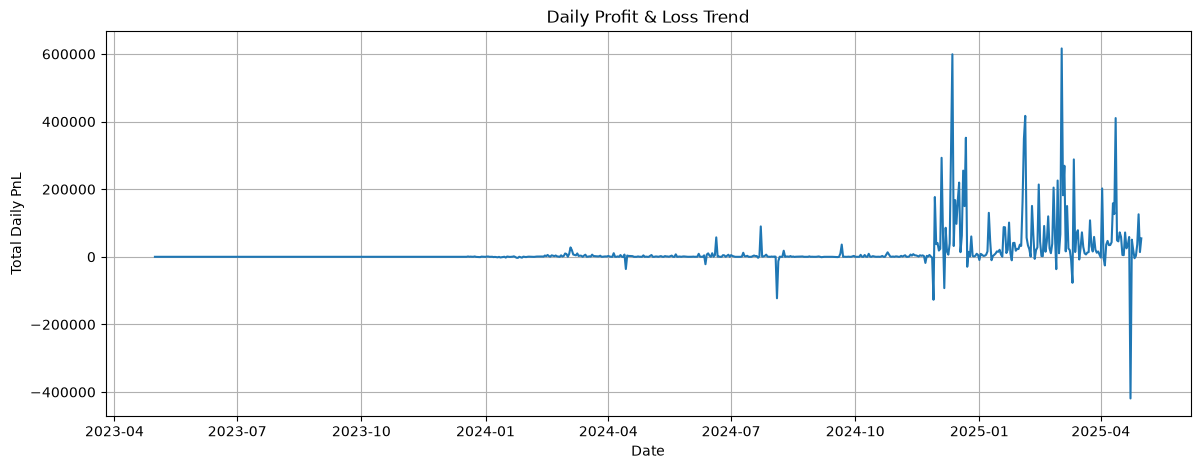

In [45]:
daily_pnl = merged.groupby("Date")["PnL"].sum()

plt.figure(figsize=(14,5))

daily_pnl.plot()

plt.title("Daily Profit & Loss Trend")

plt.xlabel("Date")

plt.ylabel("Total Daily PnL")

plt.grid(True)

plt.show()

### Trader Segmentation using Machine Learning

K-Means clustering was applied to automatically group traders according to their trading behavior.

In [46]:
trader = merged.groupby("Account").agg({

    "PnL":"sum",

    "Size_USD":"mean",

    "Fee":"mean"

})

trader.head()

,PnL,Size_USD,Fee
Account,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,16159.576734,1.939579
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,1653.226327,0.374978
0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,8893.000898,2.436593
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,507.626933,0.166657
0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,3138.894782,0.959616


In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled = scaler.fit_transform(trader)

In [48]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

trader["Cluster"] = kmeans.fit_predict(scaled)

trader.head()

,PnL,Size_USD,Fee,Cluster
Account,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,16159.576734,1.939579,0
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,1653.226327,0.374978,1
0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,8893.000898,2.436593,1
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,507.626933,0.166657,1
0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,3138.894782,0.959616,1


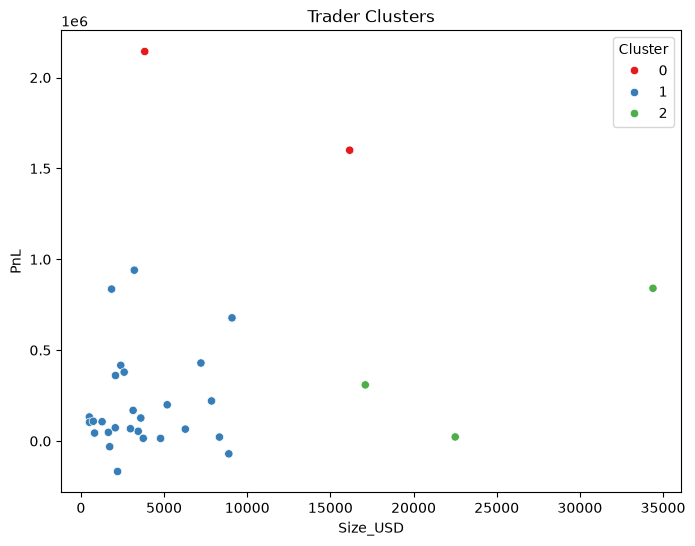

In [49]:
plt.figure(figsize=(8,6))

sns.scatterplot(

    data=trader,

    x="Size_USD",

    y="PnL",

    hue="Cluster",

    palette="Set1"

)

plt.title("Trader Clusters")

plt.show()